In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.tri as mtri
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
#
#seleting simulation to analyze by folder:
#

#Simons 10x run
#datadir = "/gpfs/data/fs72044/icon01/volcano_modeling/expdir/10x_vulc/10x_vulc"
#Raphaels 10x run
#datadir = "/gpfs/data/fs72044/icon09/model_output/4exp_slabctr_simonx10/4exp_slabctr_simonx10"
datadir = "/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/9exp_slabctr_10pinatubo_rampup_decay_Raphael/9exp_slabctr_10pinatubo_rampup_decay_Raphael"
datadir_full = datadir+"_atm_2d_ml_"+str(2000)+"0101T000000Z.nc"
data = xr.open_dataset(datadir_full)

#
#getting grid to get weights for averaging
#
griddir = "/gpfs/data/fs72044/icon01/volcano_modeling/data/ICON-inputdata/amip-VSC4/grid/icon_grid_0013_R02B04_G.nc"
grid = xr.open_dataset(griddir)
grid_area = grid["cell_area"]
weights = grid_area
weights = weights.rename({"cell": "ncells"})
weights = weights.assign_coords(
    {
        "cell": data.ncells,
        "clon": data.clon,
        "clat": data.clat,
    }
)


In [13]:
#
#get and take mean of control data to compare to
#
ctrl_dir = "/gpfs/data/fs72044/avoigt_teach/experiments/s2026/slabctr/slabctr"

startyear = 1985
ctrdir_full = ctrl_dir+"_atm_2d_ml_"+str(startyear)+"0101T000000Z.nc"
ctr_year = xr.open_dataset(ctrdir_full)

ctr = ctr_year.mean("time")
ctr_years = []
for i in range(44):
    year = startyear +1 +i
    ctrdir_full = ctrl_dir+"_atm_2d_ml_"+str(year)+"0101T000000Z.nc"
    ctr_year = xr.open_dataset(ctrdir_full)
    ctr += ctr_year.mean("time")
    ctr_years.append(ctr_year["ts"].mean("ncells").mean("time"))

ctr = ctr/45

In [14]:
#
#load and merge data, take means
#
startyears = [2006, 2025]
years_s = [3, 10]
temp_anomaly_values = []
rad_bal_anomaly_values = []
rad_bal_values = []
for j in range(len(startyears)):
    startyear = startyears[j]
    years = years_s[j]
    endyear = startyear + years
    for i in range(years):
        year = startyear + i
        datadir_full = datadir + "_atm_2d_ml_" + str(year) + "0101T000000Z.nc"
        data = xr.open_dataset(datadir_full)
        if i == 0:
            datafull = data[["rsut", "rlut", "rsdt", "ts"]]
        else:
            datafull = datafull.merge(data[["rsut", "rlut", "rsdt", "ts"]])

    mean_temp = datafull.ts.mean("time")
    mean_sw = datafull.rsut.mean("time")
    mean_lw = datafull.rlut.mean("time")
    mean_sw_in = datafull.rsdt.mean("time")
    mean_rad_balance = mean_sw_in - mean_sw - mean_lw
    mean_rad_bal_dif = mean_rad_balance - (ctr.rsdt - ctr.rsut - ctr.rlut)

    temp_anomaly_values.append((mean_temp.values - ctr["ts"]).copy())
    rad_bal_anomaly_values.append(mean_rad_bal_dif.copy())
    rad_bal_values.append(mean_rad_balance.copy())


temp_anomaly_vmin = min(v.min() for v in temp_anomaly_values)
temp_anomaly_vmax = max(v.max() for v in temp_anomaly_values)
rad_bal_anomaly_vmin = min(v.min() for v in rad_bal_anomaly_values)
rad_bal_anomaly_vmax = max(v.max() for v in rad_bal_anomaly_values)


In [15]:
#
#create colormap to shift 0 anomaly to be at white
#
vmin = temp_anomaly_vmin
vmax = temp_anomaly_vmax
zero_pos = (0 - vmin) / (vmax - vmin)
lat = datafull.clat*180/np.pi
lon = datafull.clon*180/np.pi
cmap_temp = mpl.colors.LinearSegmentedColormap.from_list(
    "asym_blue_white_red",
    [
        (0.0, "#034282"),          
        (zero_pos * 0.8, "#6baed6"),
        (zero_pos, "#ffffff"),    
        (1.0, "#ffd6ad"),          
    ],
)
rvmin = rad_bal_anomaly_vmin
rvmax = rad_bal_anomaly_vmax
zero_pos = (0 - rvmin) / (rvmax - rvmin)
cmap_rad = mpl.colors.LinearSegmentedColormap.from_list(
    "asym_blue_white_red",
    [
        (0.0, "#034282"),         
        (zero_pos * 0.8, "#6baed6"),
        (zero_pos, "#ffffff"),    
        (1.0, "#fdae61"),          
    ],
)

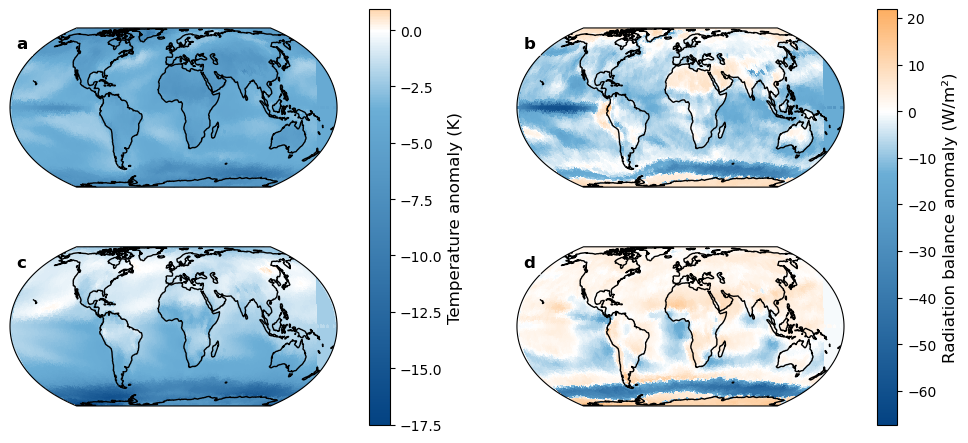

In [16]:
#
#plotting
#
fig, ax = plt.subplots(len(startyears), 2, figsize=(12, 3*len(startyears)),
                       subplot_kw={'projection': ccrs.EqualEarth()})


for j in range(len(startyears)):
    #
	#temperature anomaly
	#
    ax[j,0].coastlines()
    ax[j,0].set_global()

    img = ax[j,0].tripcolor(
        lon, lat, temp_anomaly_values[j],
        transform=ccrs.PlateCarree(),   # lon/lat coordinate system of the data
        cmap=cmap_temp,
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
        shading='flat'
    )

	#
    #radiation balance anomaly
    #
    ax[j,1].coastlines()
    ax[j,1].set_global()
    img2 = ax[j,1].tripcolor(
        lon, lat, rad_bal_anomaly_values[j],#rad_bal_anomaly_values[j].values if hasattr(rad_bal_anomaly_values[j],'values') else rad_bal_anomaly_values[j],
        transform=ccrs.PlateCarree(),
        cmap=cmap_rad,
        norm=mpl.colors.Normalize(vmin=rvmin, vmax=rvmax),
        shading='flat'
    )

# colorbars
cbar_temp_anomaly = fig.colorbar(img, ax=ax[:,0], label='Temperature (K)', pad=0.22, shrink=0.9)
cbar_temp_anomaly.set_label("Temperature anomaly (K)", fontsize=12)
cbar_temp_anomaly.ax.tick_params(labelsize=10)

cbar_rad_bal_anomaly= fig.colorbar(img2, ax=ax[:,1], label='Radiation balance anomaly (W/m²)', pad=0.22, shrink=0.9)
cbar_rad_bal_anomaly.set_label("Radiation balance anomaly (W/m²)", fontsize=12)
cbar_rad_bal_anomaly.ax.tick_params(labelsize=10)


#lettering
letters = list('abcdefghijklmnopqrstuvwxyz')

for j in range(len(startyears)):
    idx = j*2 + 0
    ax[j,0].text(0.02, 0.95, f'{letters[idx]}',#0.98, 0.05+0.9*j
                 transform=ax[j,0].transAxes,
                 fontsize=12, fontweight='bold',
                 va='top', ha='left',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    idx = j*2 + 1
    ax[j,1].text(0.02, 0.95, f'{letters[idx]}',#0.02, 0.05+0.9*j
                 transform=ax[j,1].transAxes,
                 fontsize=12, fontweight='bold',
                 va='top', ha='left',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
#
#fixing location so colorbars do not overlap
#
fig.subplots_adjust(hspace=-0.1, wspace=0.55)
fig.subplots_adjust(right=0.82)
plt.show()

In [17]:
#
#printing global average values for plot above
#
temp_anomaly_means = []
rad_bal_anomaly_means = []
rad_bal_means = []
for i in range(len(temp_anomaly_values)):
    weighted_temp_anomaly =temp_anomaly_values[i].weighted(weights)
    mean_temp_anomaly = weighted_temp_anomaly.mean(dim='ncells')
    temp_anomaly_means.append(mean_temp_anomaly)
    print(f"Mean temperature anomaly for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_temp_anomaly:.4f} K")

    weighted_rad_bal_anomaly =rad_bal_anomaly_values[i].weighted(weights)
    mean_rad_bal_anomaly = weighted_rad_bal_anomaly.mean(dim='ncells')
    rad_bal_anomaly_means.append(mean_rad_bal_anomaly)
    print(f"Mean radiative balance anomaly for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_rad_bal_anomaly:.4f} W/m²")

    weighted_rad_bal =rad_bal_values[i].weighted(weights)
    mean_rad_bal = weighted_rad_bal.mean(dim='ncells')
    rad_bal_means.append(mean_rad_bal)
    print(f"Mean radiative balance for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_rad_bal:.4f} W/m²")

    


Mean temperature anomaly for timeframe 2006-2009: -4.3836 K
Mean radiative balance anomaly for timeframe 2006-2009: -6.7290 W/m²
Mean radiative balance for timeframe 2006-2009: -5.6275 W/m²
Mean temperature anomaly for timeframe 2025-2035: -3.1219 K
Mean radiative balance anomaly for timeframe 2025-2035: -0.9760 W/m²
Mean radiative balance for timeframe 2025-2035: 0.1254 W/m²


In [18]:
#
#printing global average values for the other simulations
#

datadirs = ["/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/10exp_slabctr_5pinatubo_rampup_decay_Raphael/10exp_slabctr_5pinatubo_rampup_decay_Raphael",
            "/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/11exp_slabctr_20pinatubo_rampup_decay_Raphael/11exp_slabctr_20pinatubo_rampup_decay_Raphael"
    ]

factors = [5, 20]
for data_inx in range(2):
    datadir = datadirs[data_inx]
    #datadir_full = datadir+"_atm_2d_ml_"+str(2000)+"0101T000000Z.nc"
    #data = xr.open_dataset(datadir_full)

    startyears = [2006, 2025]
    years_s = [3, 10]
    temp_anomaly_values = []
    rad_bal_anomaly_values = []
    rad_bal_values = []
    for j in range(len(startyears)):
        startyear = startyears[j]
        years = years_s[j]
        endyear = startyear + years
        for i in range(years):
            year = startyear + i
            datadir_full = datadir + "_atm_2d_ml_" + str(year) + "0101T000000Z.nc"
            data = xr.open_dataset(datadir_full)
            if i == 0:
                datafull = data[["rsut", "rlut", "rsdt", "ts"]]
            else:
                datafull = datafull.merge(data[["rsut", "rlut", "rsdt", "ts"]])

        mean_temp = datafull.ts.mean("time")
        mean_sw = datafull.rsut.mean("time")
        mean_lw = datafull.rlut.mean("time")
        mean_sw_in = datafull.rsdt.mean("time")
        mean_rad_balance = mean_sw_in - mean_sw - mean_lw
        mean_rad_bal_dif = mean_rad_balance - (ctr.rsdt - ctr.rsut - ctr.rlut)

        temp_anomaly_values.append((mean_temp.values - ctr["ts"]).copy())
        rad_bal_anomaly_values.append(mean_rad_bal_dif.copy())
        rad_bal_values.append(mean_rad_balance.copy())

    print(str(factors[data_inx])+"times pinatubo eruption:")
    temp_anomaly_means = []
    rad_bal_anomaly_means = []
    rad_bal_means = []
    for i in range(len(temp_anomaly_values)):
        weighted_temp_anomaly =temp_anomaly_values[i].weighted(weights)
        mean_temp_anomaly = weighted_temp_anomaly.mean(dim='ncells')
        temp_anomaly_means.append(mean_temp_anomaly)
        print(f"Mean temperature anomaly for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_temp_anomaly:.4f} K")

        weighted_rad_bal_anomaly =rad_bal_anomaly_values[i].weighted(weights)
        mean_rad_bal_anomaly = weighted_rad_bal_anomaly.mean(dim='ncells')
        rad_bal_anomaly_means.append(mean_rad_bal_anomaly)
        print(f"Mean radiative balance anomaly for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_rad_bal_anomaly:.4f} W/m²")

        weighted_rad_bal =rad_bal_values[i].weighted(weights)
        mean_rad_bal = weighted_rad_bal.mean(dim='ncells')
        rad_bal_means.append(mean_rad_bal)
        print(f"Mean radiative balance for timeframe {startyears[i]}-{startyears[i] + years_s[i]}: {mean_rad_bal:.4f} W/m²")




5times pinatubo eruption:
Mean temperature anomaly for timeframe 2006-2009: -2.4365 K
Mean radiative balance anomaly for timeframe 2006-2009: -3.5828 W/m²
Mean radiative balance for timeframe 2006-2009: -2.4813 W/m²
Mean temperature anomaly for timeframe 2025-2035: -2.1771 K
Mean radiative balance anomaly for timeframe 2025-2035: -0.9442 W/m²
Mean radiative balance for timeframe 2025-2035: 0.1573 W/m²
20times pinatubo eruption:
Mean temperature anomaly for timeframe 2006-2009: -7.6703 K
Mean radiative balance anomaly for timeframe 2006-2009: -11.2444 W/m²
Mean radiative balance for timeframe 2006-2009: -10.1429 W/m²
Mean temperature anomaly for timeframe 2025-2035: -4.9403 K
Mean radiative balance anomaly for timeframe 2025-2035: -1.2436 W/m²
Mean radiative balance for timeframe 2025-2035: -0.1421 W/m²


In [ ]:
#
#printing table for initial yearly values after the eruption and means 20 years later
#

#selecting save file directories
datadirs = ["/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/10exp_slabctr_5pinatubo_rampup_decay_Raphael/10exp_slabctr_5pinatubo_rampup_decay_Raphael",
            "/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/9exp_slabctr_10pinatubo_rampup_decay_Raphael/9exp_slabctr_10pinatubo_rampup_decay_Raphael",
            "/gpfs/data/fs72044/icon09/model_output/Raphael_input_runs/11exp_slabctr_20pinatubo_rampup_decay_Raphael/11exp_slabctr_20pinatubo_rampup_decay_Raphael"
    ]

factors = [5, 10, 20]
ctr_mean = ctr.weighted(weights).mean("ncells")


#variables to look at (surface temp, sea ice coverage and precipitation)
variables = ["ts","sic","pr"]#"rsut", "rlut", "rsdt", "ts"]
for data_inx in range(3):
	#selecting file
	datadir = datadirs[data_inx]

	#
	#years directly before and following the eruption
	#
	startyear =2004
	years = 6
	mean_data_ys = []
	years_s = []
	sea_ice_latitudes = []
	endyear = startyear + years
	for i in range(years):
		year = startyear + i
		years_s.append(year)
		datadir_full = datadir + "_atm_2d_ml_" + str(year) + "0101T000000Z.nc"
		data = xr.open_dataset(datadir_full)
		mean_data  = data[variables].mean("time").weighted(weights).mean("ncells")
		mean_data_ys.append(mean_data)
		#
		#selecting sea ice borders:
		#
		mask = (data["sic"]>0.9) & (data["clat"]<0)
		sea_ice_lat_s =data["clat"].where(mask).max()*180/np.pi
		mask = (data["sic"]>0.9) & (data["clat"]>0)
		sea_ice_lat_n = data["clat"].where(mask).min()*180/np.pi
		sea_ice_latitudes.append((sea_ice_lat_s, sea_ice_lat_n))
	deviations = [mean_data - ctr_mean for mean_data in mean_data_ys]	

	#
	#getting averages for 2025-2034
	#
	startyear = 2025
	years = 10

	for i in range(years):
		year = startyear + i
		datadir_full = datadir + "_atm_2d_ml_" + str(year) + "0101T000000Z.nc"
		data = xr.open_dataset(datadir_full)
		mean_data  = data[variables].mean("time").weighted(weights).mean("ncells")
		mask = (data["sic"]>0.9) & (data["clat"]<0)
		sea_ice_lat_s =data["clat"].where(mask).max()*180/np.pi
		mask = (data["sic"]>0.9) & (data["clat"]>0)
		sea_ice_lat_n = data["clat"].where(mask).min()*180/np.pi
		if i==0:
			mean_data_late = mean_data
			mean_sea_ice_lat_s_late = sea_ice_lat_s
			mean_sea_ice_lat_n_late = sea_ice_lat_n
			
		else:
			mean_data_late += mean_data
			mean_sea_ice_lat_s_late += sea_ice_lat_s
			mean_sea_ice_lat_n_late += sea_ice_lat_n
	mean_data_late = mean_data_late/years
	deviation_late = mean_data_late - ctr_mean
	mean_sea_ice_lat_s_late = mean_sea_ice_lat_s_late/years
	mean_sea_ice_lat_n_late = mean_sea_ice_lat_n_late/years
	


	print(str(factors[data_inx])+"times pinatubo eruption:")

	#
	#creating table to print
	#
	headers = ["Variable"] + years_s + ["Mean 2025-2034"]
	rows = []
	for var in mean_data_ys[0].data_vars:
		row = [var] + [f"{mean_data[var].values:.4g}" for mean_data in mean_data_ys] + [f"{mean_data_late[var].values:.4g}"]
		rows.append(row)
		#rows.append(["Deviation from control"] + [f"{deviation.values:.4f}" for deviation in deviations] + [f"{deviation_late.values:.4f}"])
		row = [var+" Deviation"] + [f"{deviation[var].values:.4g}" for deviation in deviations] + [f"{deviation_late[var].values:.4g}"]
		rows.append(row)
	row = ["relative precipitation deviation"] + [f"{deviation['pr'].values/mean_data['pr'].values:.4g}" for deviation, mean_data in zip(deviations, mean_data_ys)] + [f"{deviation_late['pr'].values/mean_data_late['pr'].values:.4g}"]
	rows.append(row)
	row = ["sea ice latitudes"] + [(f"{lat_s:.4g}", f"{lat_n:.4g}") for lat_s, lat_n in sea_ice_latitudes] + [f"({mean_sea_ice_lat_s_late.values:.4g}, {mean_sea_ice_lat_n_late.values:.4g})"]
	rows.append(row)
	print(tabulate(rows, headers=headers, tablefmt="grid"))


5times pinatubo eruption:
+----------------------------------+------------------+---------------------+---------------------+---------------------+---------------------+---------------------+------------------+
| Variable                         | 2004             | 2005                | 2006                | 2007                | 2008                | 2009                | Mean 2025-2034   |
+==================================+==================+=====================+=====================+=====================+=====================+=====================+==================+
| ts                               | 287.7            | 287.6               | 286.1               | 284.9               | 285.1               | 285.3               | 285.4            |
+----------------------------------+------------------+---------------------+---------------------+---------------------+---------------------+---------------------+------------------+
| ts Deviation                     | -0.07282    

In [29]:
#
#temperature drop in last final years of simulation
#
print("temperature drop in final 5 years of simulations")
startyear = 2035
years = 5
for data_inx in range(3):
	#selecting file
	datadir = datadirs[data_inx]
	for i in range(years):
		year = startyear + i
		datadir_full = datadir + "_atm_2d_ml_" + str(year) + "0101T000000Z.nc"
		data = xr.open_dataset(datadir_full)
		mean_data  = data[variables].mean("time").weighted(weights).mean("ncells")
		if i==0:
			mean_data_late = mean_data

				
		else:
			mean_data_late += mean_data
			
	mean_data_late = mean_data_late/years
	deviation_late = mean_data_late - ctr_mean

	print(str(factors[data_inx])+" times pinatubo eruption:")
	print(deviation_late["ts"].values)



temperature drop in final 5 years of simulations
5 times pinatubo eruption:
-2.4137889432329303
10 times pinatubo eruption:
-2.6227816473435723
20 times pinatubo eruption:
-4.142464024044102
